In [8]:
import zipfile
from google.colab import files

project_files = [
    "sales_forecasting_model.pkl",
    "sales_cleaned.csv",
    "sales_forecast_next_12_months.csv",
    "sales_forecast_comparison.png",
    "sales_forecast_future.png"
]

with zipfile.ZipFile("Sales_Forecasting_Project_Files.zip", "w") as z:
    for file in project_files:
        z.write(file)

files.download("Sales_Forecasting_Project_Files.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

SALES FORECASTING MODEL RESULTS
MAE: 2.34
RMSE: 3.20
R2 Score: 0.337


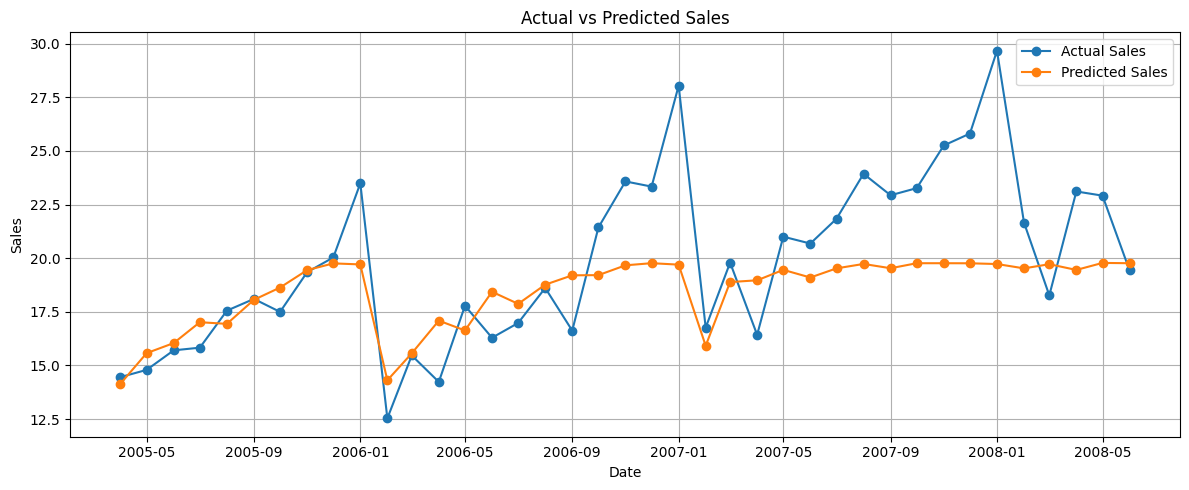

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/


NEXT 12 MONTHS FORECAST


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


,Date,Forecast_Sales
0,2008-07-01,19.76
1,2008-08-01,19.76
2,2008-09-01,19.76
3,2008-10-01,19.76
4,2008-11-01,19.76
5,2008-12-01,19.76
6,2009-01-01,19.76
7,2009-02-01,19.76
8,2009-03-01,19.76
9,2009-04-01,19.76


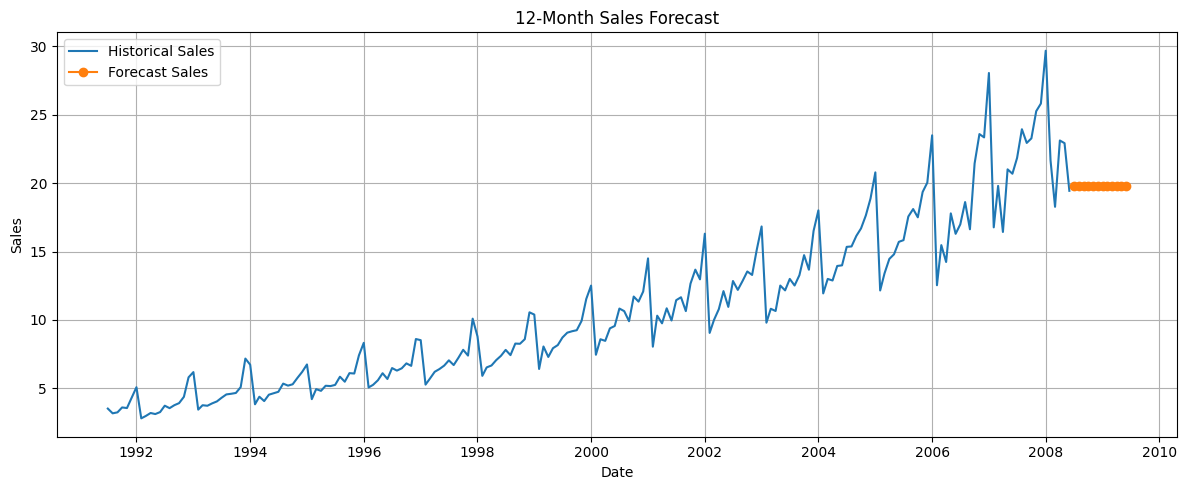


Project model and output files saved successfully!


In [7]:
# PROJECT 3: SALES FORECASTING - COMPLETE MODEL

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import files

# Prepare dataset
data = df[["date", "value"]].copy()
data["date"] = pd.to_datetime(data["date"])
data["value"] = pd.to_numeric(data["value"])
data = data.dropna().sort_values("date").reset_index(drop=True)

# Create previous-month sales features
for i in range(1, 13):
    data[f"lag_{i}"] = data["value"].shift(i)

model_data = data.dropna().reset_index(drop=True)
features = [f"lag_{i}" for i in range(1, 13)]

X = model_data[features]
y = model_data["value"]

# Chronological train-test split
split = int(len(model_data) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Train model
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate model
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("SALES FORECASTING MODEL RESULTS")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.3f}")

# Plot actual vs predicted sales
plt.figure(figsize=(12, 5))
plt.plot(model_data["date"].iloc[split:], y_test.values,
         label="Actual Sales", marker="o")
plt.plot(model_data["date"].iloc[split:], predictions,
         label="Predicted Sales", marker="o")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("sales_forecast_comparison.png", dpi=150)
plt.show()

# Forecast next 12 months recursively
history = data["value"].tolist()
future_values = []

for _ in range(12):
    lag_values = np.array(history[-12:][::-1]).reshape(1, -1)
    next_value = float(model.predict(lag_values)[0])
    future_values.append(next_value)
    history.append(next_value)

last_date = data["date"].max()
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=12,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Sales": future_values
})

print("\nNEXT 12 MONTHS FORECAST")
display(forecast_df.round(2))

plt.figure(figsize=(12, 5))
plt.plot(data["date"], data["value"], label="Historical Sales")
plt.plot(future_dates, future_values,
         label="Forecast Sales", marker="o")
plt.title("12-Month Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("sales_forecast_future.png", dpi=150)
plt.show()

# Save model and project files
joblib.dump(model, "sales_forecasting_model.pkl")
data[["date", "value"]].to_csv("sales_cleaned.csv", index=False)
forecast_df.to_csv("sales_forecast_next_12_months.csv", index=False)

print("\nProject model and output files saved successfully!")

In [6]:
from sklearn.model_selection import train_test_split

# Features and target
X = model_df[[f"lag_{i}" for i in range(1, 13)]]
y = model_df["value"]

# Keep time order: do not shuffle time-series data
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 153
Testing rows: 39


In [5]:
# Step 6: Prepare data for forecasting

# Make sure data is sorted by date
df = df.sort_values("date").reset_index(drop=True)

# Use the previous 12 months to predict the next month
for i in range(1, 13):
    df[f"lag_{i}"] = df["value"].shift(i)

# Remove rows that have missing lag values
model_df = df.dropna().copy()

print("Prepared dataset shape:", model_df.shape)
display(model_df.head())

Prepared dataset shape: (192, 14)


,date,value,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12
12,1992-07-01,3.737851,3.270523,3.127578,3.204780,2.985811,2.814520,5.088335,4.306371,3.565869,3.611003,3.252221,3.180891,3.526591
13,1992-08-01,3.558776,3.737851,3.270523,3.127578,3.204780,2.985811,2.814520,5.088335,4.306371,3.565869,3.611003,3.252221,3.180891
14,1992-09-01,3.777202,3.558776,3.737851,3.270523,3.127578,3.204780,2.985811,2.814520,5.088335,4.306371,3.565869,3.611003,3.252221
15,1992-10-01,3.924490,3.777202,3.558776,3.737851,3.270523,3.127578,3.204780,2.985811,2.814520,5.088335,4.306371,3.565869,3.611003
16,1992-11-01,4.386531,3.924490,3.777202,3.558776,3.737851,3.270523,3.127578,3.204780,2.985811,2.814520,5.088335,4.306371,3.565869


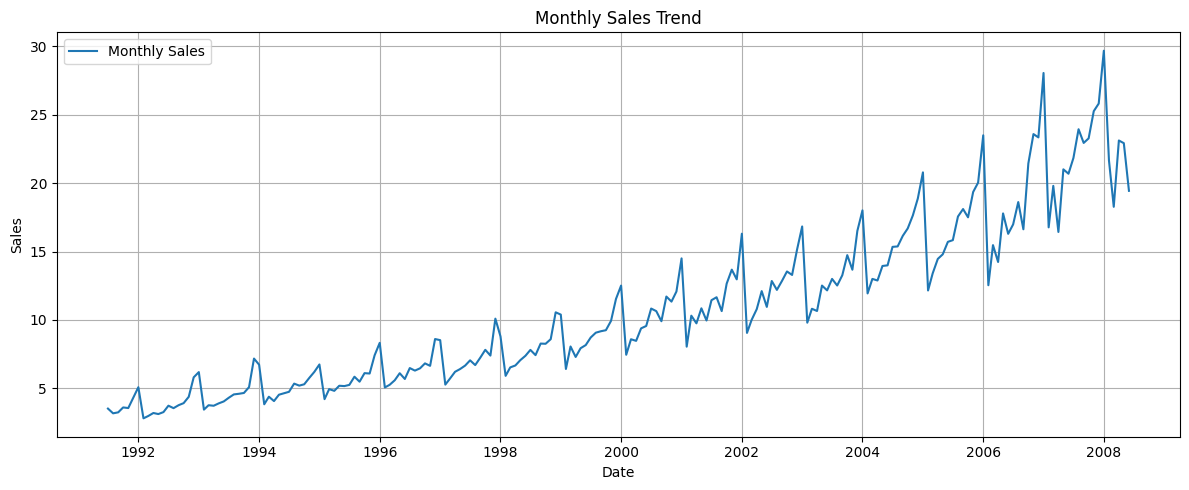

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["value"], label="Monthly Sales")

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Sort data by date
df = df.sort_values("date").reset_index(drop=True)

print("Start Date:", df["date"].min())
print("End Date:", df["date"].max())

display(df.head())

Start Date: 1991-07-01 00:00:00
End Date: 2008-06-01 00:00:00


,date,value
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869


In [2]:
# Step 3: Check dataset information
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(204, 2)

Column Names:
['date', 'value']

Data Types:
date      object
value    float64
dtype: object

Missing Values:
date     0
value    0
dtype: int64

Duplicate Rows:
0

Statistical Summary:


,value
count,204.000000
mean,10.694430
std,5.956998
min,2.814520
25%,5.844095
50%,9.319345
75%,14.289964
max,29.665356


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load sample retail sales dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/a10.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
display(df.head())
print(df.info())

Dataset loaded successfully!
Dataset shape: (204, 2)


,date,value
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    204 non-null    object 
 1   value   204 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.3+ KB
None
